### Implement Standard Normal Distribution and Standard Normal Distribution and Z-score with code

## Plan of action

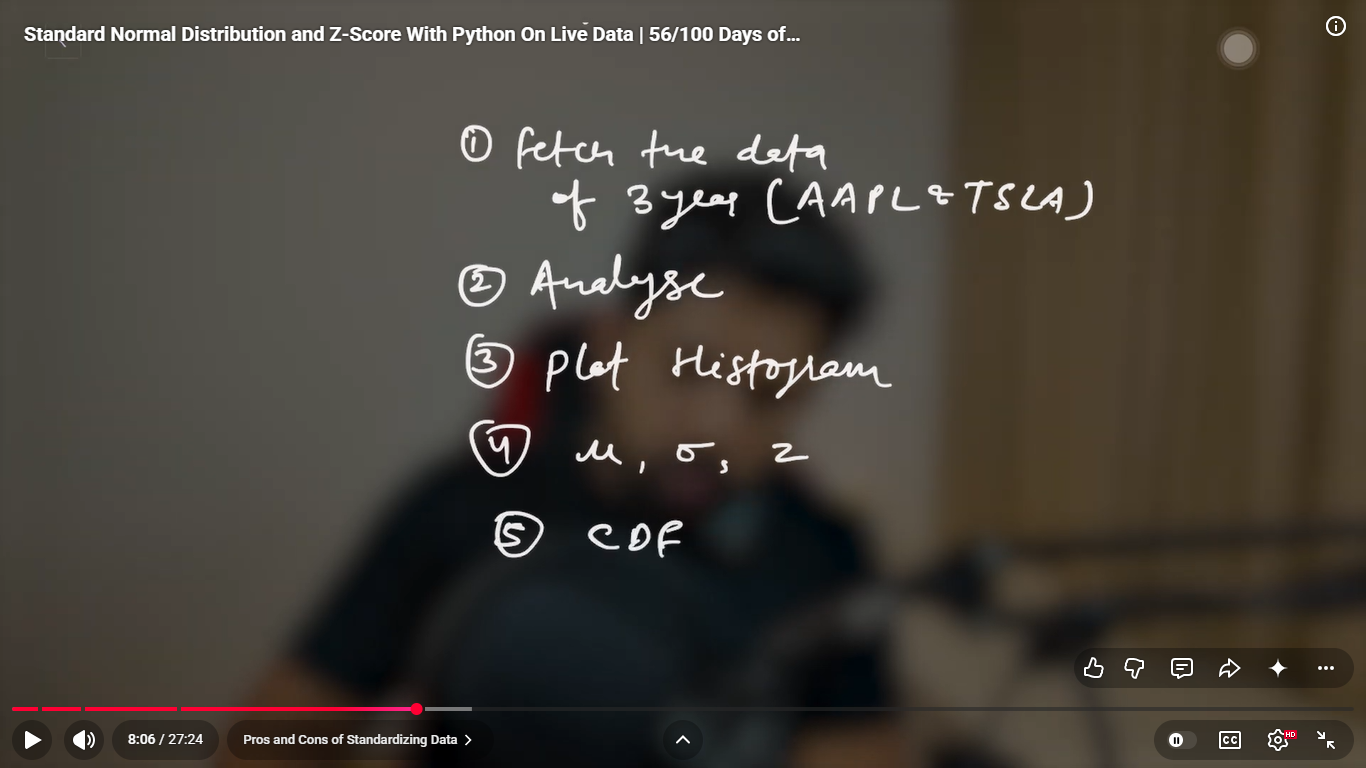

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import seaborn as sns
import yfinance as yf

In [4]:
apple =  yf.download(tickers='AAPL',start='2023-06-26',end='2026-06-26',auto_adjust=False)
tesla = yf.download(tickers='TSLA',start='2023-06-26',end='2026-06-26',auto_adjust=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [28]:
adani_green = yf.download(tickers='ADANIGREEN.NS',period='3y', auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [6]:
apple['Close']
tesla['Close']

Ticker,TSLA
Date,
2023-06-26,241.050003
2023-06-27,250.210007
2023-06-28,256.239990
2023-06-29,257.500000
2023-06-30,261.769989
...,...
2026-06-18,400.489990
2026-06-22,405.049988
2026-06-23,381.609985


In [11]:
tesla['Close'].describe()

Ticker,TSLA
count,753.000000
mean,303.260770
std,91.617797
min,142.050003
25%,230.039993
50%,279.820007
75%,394.359985
max,489.880005


In [29]:
adani_green['Close']

Ticker,ADANIGREEN.NS
Date,
2023-06-26,968.450012
2023-06-27,959.549988
2023-06-28,956.650024
2023-06-30,945.900024
2023-07-03,942.849976
...,...
2026-06-19,1502.400024
2026-06-22,1549.900024
2026-06-23,1511.199951


In [30]:
adani_green['Close'].describe()

Ticker,ADANIGREEN.NS
count,742.000000
mean,1262.946228
std,381.052533
min,768.549988
25%,965.750015
50%,1038.424988
75%,1680.687531
max,2070.550049


In [31]:
pct_apple = apple['Close'].pct_change()
pct_tesla = tesla['Close'].pct_change()
pct_adani_green = adani_green['Close'].pct_change()

<Axes: ylabel='Count'>

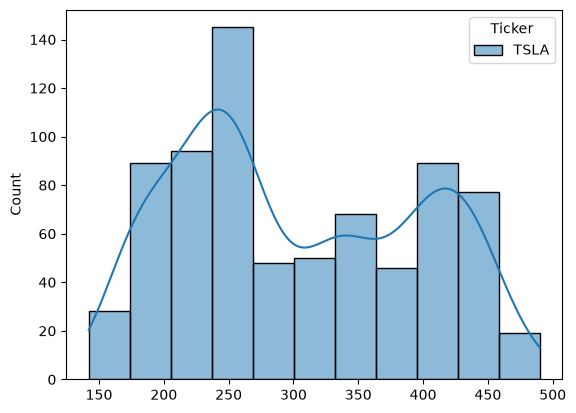

In [10]:
# sns.histplot(apple['Close'], kde=True)
sns.histplot(tesla['Close'], kde=True)

<Axes: ylabel='Count'>

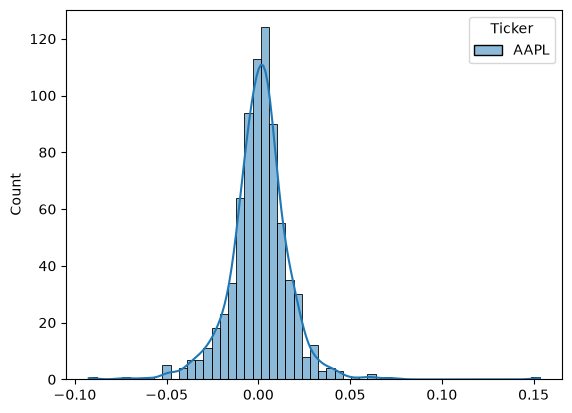

In [ ]:
sns.histplot(pct_apple,kde=True) #  -  it is close to normal distribution

<Axes: ylabel='Count'>

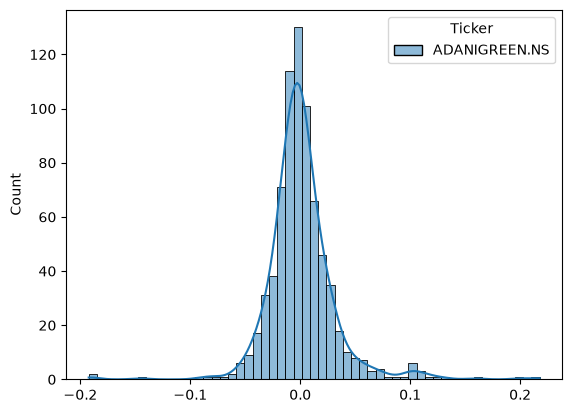

In [32]:
sns.histplot(pct_adani_green,kde=True)


### find the CDF Normal distribution

In [ ]:
# daily percentage returns ka statistical summary hai
pct_apple.describe()

Ticker,AAPL
count,752.000000
mean,0.000661
std,0.016517
min,-0.092456
25%,-0.007026
50%,0.001165
75%,0.007979
max,0.153289


In [ ]:
# daily percentage returns ka statistical summary hai
pct_tesla.describe() 
# after observation s.d tesla is more volatile on both side upar and lower
# conclusion: tesla is high risk and reward stock

Ticker,TSLA
count,752.000000
mean,0.001242
std,0.036398
min,-0.154262
25%,-0.019821
50%,0.000390
75%,0.020837
max,0.226900


In [ ]:
# daily percentage returns ka statistical summary hai
pct_adani_green.describe()

Ticker,ADANIGREEN.NS
count,741.000000
mean,0.001100
std,0.031403
min,-0.192345
25%,-0.013112
50%,-0.001405
75%,0.012173
max,0.217715


In [ ]:
# Normal Distribution
# apple ka cdf
# 2nd paratmeter : mean
# 3sd paramter - std
cdf_apple = norm.cdf(pct_apple,loc=0.000661,scale=0.016517)
cdf_tesla = norm.cdf(pct_tesla,loc=0.001242,scale=0.031403)

In [49]:
# first standdized the data then find the cdf
# calculate z score
# find the CDF standard normal distribution means mean = 0 and s.d = 1
z_apple = (pct_apple - pct_apple.mean())/pct_apple.std()
z_tesla = (pct_tesla - pct_tesla.mean())/pct_tesla.std()

# by default it is assume that data is standardized

In [51]:
# Standard Distribution
# Property of Standard Distribution - the area under the curve is 1
cdf_apple_after_standard_normalixzed = norm.cdf(z_apple)
cdf_tesla_after_standard_normalixzed   =  norm.cdf(z_tesla)
cdf_apple_after_standard_normalixzed

array([[           nan],
       [8.08305562e-01],
       [6.34221179e-01],
       [5.27394316e-01],
       [9.12869715e-01],
       [3.04552590e-01],
       [3.46231562e-01],
       [5.44524482e-01],
       [3.45787251e-01],
       [2.42811477e-01],
       [4.16766536e-01],
       [6.92856182e-01],
       [5.81450114e-01],
       [5.03039141e-01],
       [8.43195858e-01],
       [4.51769078e-01],
       [6.51027575e-01],
       [2.57404230e-01],
       [3.39770497e-01],
       [5.85290612e-01],
       [5.92204165e-01],
       [5.92942458e-01],
       [3.30520846e-01],
       [7.81644392e-01],
       [5.60260981e-01],
       [3.82500889e-01],
       [1.64073919e-01],
       [3.14434919e-01],
       [1.60277963e-03],
       [1.39042799e-01],
       [6.10851048e-01],
       [2.80226470e-01],
       [4.54303895e-01],
       [4.59663269e-01],
       [7.01472942e-01],
       [2.36334551e-01],
       [3.66822009e-01],
       [1.78458747e-01],
       [5.51894524e-01],
       [6.65805037e-01],


In [52]:
# ser_apple_std = pd.Series(cdf_apple_after_standard_normalixzed)
# ser_tesla_std = pd.Series(z_tesla)
ser_apple_std = pd.Series(
    cdf_apple_after_standard_normalixzed.flatten()
)

<Axes: ylabel='Count'>

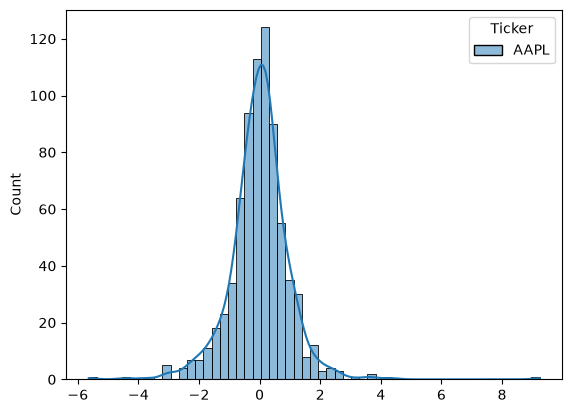

In [53]:
sns.histplot(z_apple,kde=True)

<Axes: ylabel='Count'>

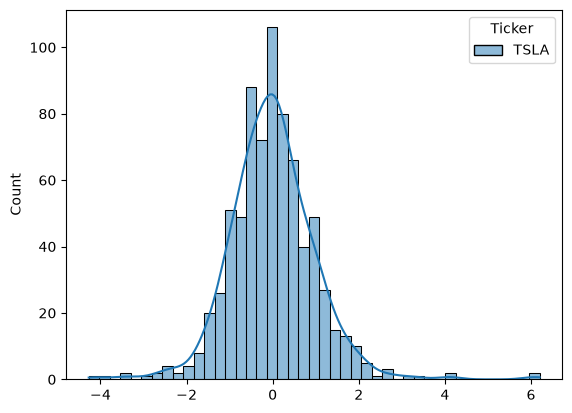

In [54]:
sns.histplot(z_tesla,kde=True)

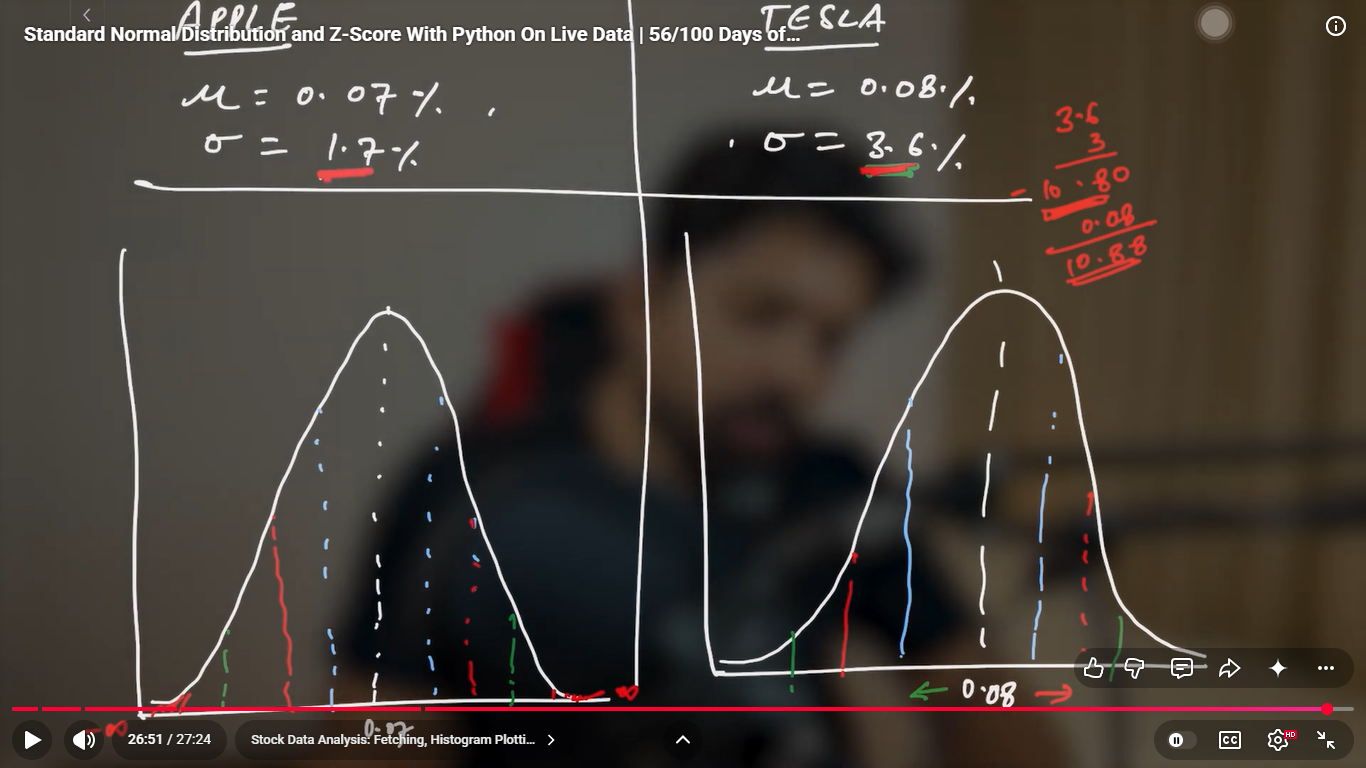

above pic shows 
    giving good return  but apple is lest volatile
    giving more return  but  tesla is more volatile